In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import sys

import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))




2.10.0
True
NVIDIA GeForce RTX 4070 Ti


In [4]:
import os

path_a = "../data/raw/set_A/"
files = os.listdir(path_a)
print(files)
print(os.path.getsize(os.path.join(path_a, files[0])) / 1024, "KB")


['Z001.txt', 'Z002.txt', 'Z003.txt', 'Z004.txt', 'Z005.txt', 'Z006.txt', 'Z007.txt', 'Z008.txt', 'Z009.txt', 'Z010.txt', 'Z011.txt', 'Z012.txt', 'Z013.txt', 'Z014.txt', 'Z015.txt', 'Z016.txt', 'Z017.txt', 'Z018.txt', 'Z019.txt', 'Z020.txt', 'Z021.txt', 'Z022.txt', 'Z023.txt', 'Z024.txt', 'Z025.txt', 'Z026.txt', 'Z027.txt', 'Z028.txt', 'Z029.txt', 'Z030.txt', 'Z031.txt', 'Z032.txt', 'Z033.txt', 'Z034.txt', 'Z035.txt', 'Z036.txt', 'Z037.txt', 'Z038.txt', 'Z039.txt', 'Z040.txt', 'Z041.txt', 'Z042.txt', 'Z043.txt', 'Z044.txt', 'Z045.txt', 'Z046.txt', 'Z047.txt', 'Z048.txt', 'Z049.txt', 'Z050.txt', 'Z051.txt', 'Z052.txt', 'Z053.txt', 'Z054.txt', 'Z055.txt', 'Z056.txt', 'Z057.txt', 'Z058.txt', 'Z059.txt', 'Z060.txt', 'Z061.txt', 'Z062.txt', 'Z063.txt', 'Z064.txt', 'Z065.txt', 'Z066.txt', 'Z067.txt', 'Z068.txt', 'Z069.txt', 'Z070.txt', 'Z071.txt', 'Z072.txt', 'Z073.txt', 'Z074.txt', 'Z075.txt', 'Z076.txt', 'Z077.txt', 'Z078.txt', 'Z079.txt', 'Z080.txt', 'Z081.txt', 'Z082.txt', 'Z083.txt', 'Z0

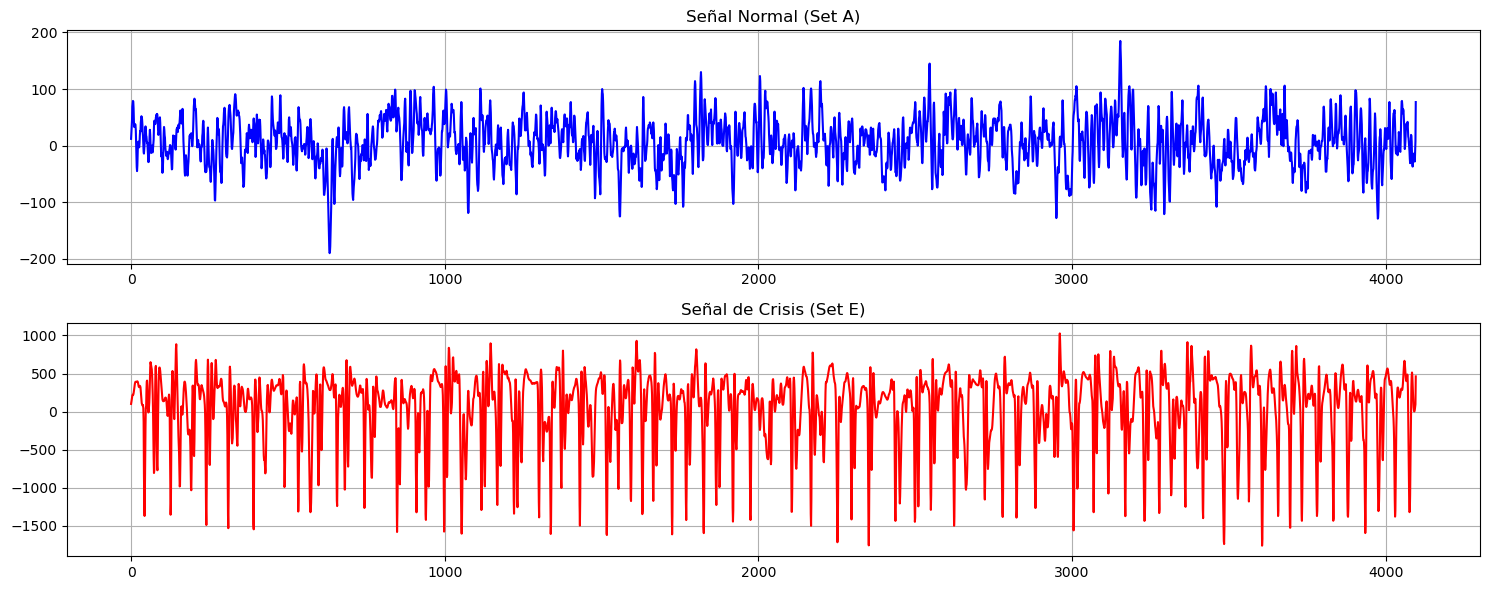

In [5]:
# Configuración
path_a = "../data/raw/set_A/"
path_e = "../data/raw/set_E/"


def load_first_file(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.txt')]
    file_path = os.path.join(folder, files[0])
    return np.genfromtxt(file_path, dtype=float, delimiter=None)
sig_normal = load_first_file(path_a)
sig_seizure = load_first_file(path_e)

plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.plot(sig_normal, color='blue')
plt.title("Señal Normal (Set A)")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(sig_seizure, color='red')
plt.title("Señal de Crisis (Set E)")
plt.grid(True)

plt.tight_layout()
plt.show()



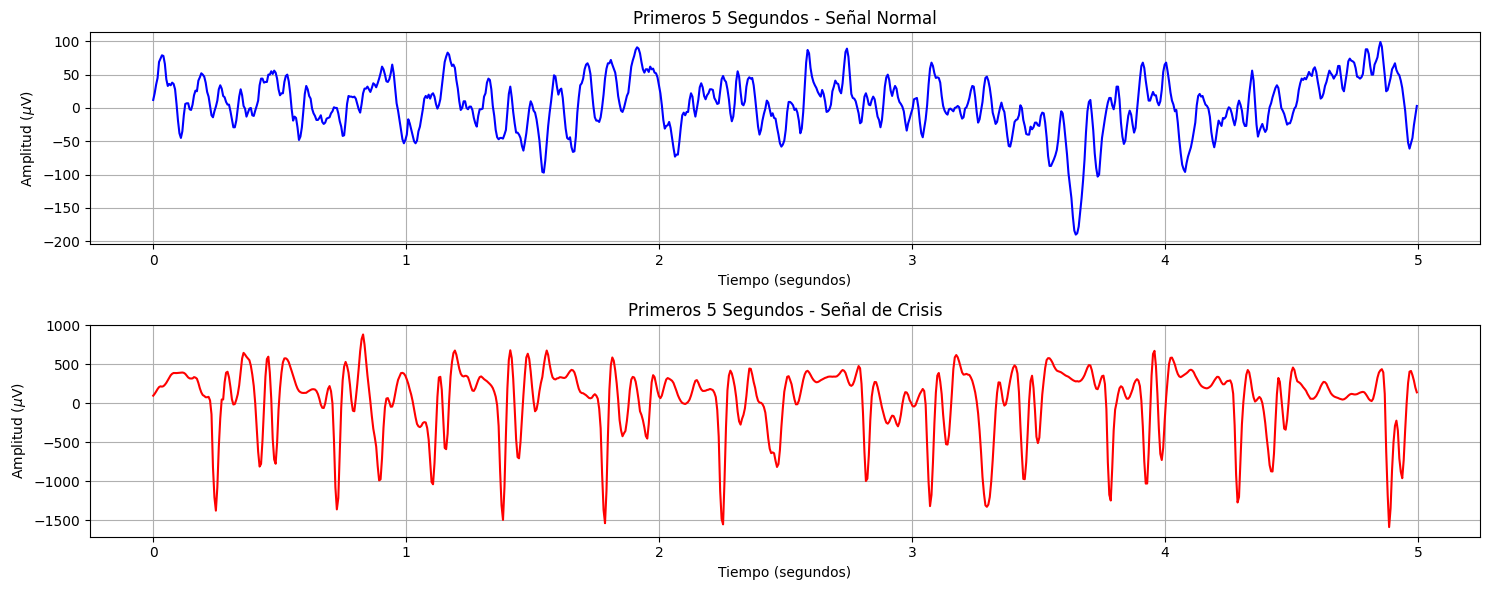

In [4]:
# --- TU EJERCICIO DE CÓDIGO ---

# 1. Definimos la frecuencia de muestreo dada por el dataset
fs = 173.61

# 2. Creamos un array que represente el tiempo en segundos para cada muestra.
# Ayuda: debe ir de 0 a (TotalMuestras / fs) en pasos de (1 / fs)
# Puedes usar np.linspace o np.arange.
n_samples = len(sig_normal)
time_seconds = np.linspace(0, n_samples / fs, n_samples)

# 3. Calculamos cuántas muestras equivalen a 5 segundos
# Ayuda: fs (muestras/seg) * 5 (seg)
samples_5s = int(fs * 5)

# 4. Visualización de los primeros 5 segundos
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
# IMPORTANTE: Ahora pasamos 'time_seconds' como eje X y recortamos la señal hasta 'samples_5s'
plt.plot(time_seconds[:samples_5s], sig_normal[:samples_5s], color='blue')
plt.title("Primeros 5 Segundos - Señal Normal")
plt.xlabel("Tiempo (segundos)") # ¡Ahora sí!
plt.ylabel("Amplitud ($\mu$V)") # Bonn suele estar en microvoltios
plt.grid(True)

plt.subplot(2, 1, 2)
# Hacemos lo mismo para la señal de crisis
plt.plot(time_seconds[:samples_5s], sig_seizure[:samples_5s], color='red')
plt.title("Primeros 5 Segundos - Señal de Crisis")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud ($\mu$V)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
import os

def build_giant_matrix(folder_path, label, window_size=174):
    """
    Lee todos los .txt de una carpeta, los trocea en ventanas 
    y les asigna una etiqueta.
    """
    all_windows = []
    all_labels = []
    
    # Listamos todos los archivos .txt de la carpeta
    files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
    
    print(f"Procesando {len(files)} archivos en {folder_path}...")
    
    for f in files:
        # Cargar la señal completa (4097 puntos)
        signal = np.loadtxt(os.path.join(folder_path, f))
        
        # Troceamos la señal en ventanas de ~1 segundo (174 puntos)
        # Sin solapamiento por ahora para hacerlo simple
        for i in range(0, len(signal) - window_size, window_size):
            window = signal[i : i + window_size]
            
            # NORMALIZACIÓN: Paso vital en EEG. 
            # Restamos media y dividimos por desviación estándar.
            window = (window - np.mean(window)) / (np.std(window) + 1e-8)
            
            all_windows.append(window)
            all_labels.append(label)
            
    return np.array(all_windows), np.array(all_labels)

# --- EJECUCIÓN ---

# Definimos las rutas (ajusta según tus carpetas)
path_a = "../data/raw/set_A/"
path_e = "../data/raw/set_E/"

# Procesamos ambos sets
X_a, y_a = build_giant_matrix(path_a, label=0) # 0 = Sano
X_e, y_e = build_giant_matrix(path_e, label=1) # 1 = Crisis

# Concatenamos todo en una sola matriz gigante
X = np.concatenate([X_a, X_e], axis=0)
y = np.concatenate([y_a, y_e], axis=0)

print("-" * 30)
print(f"Forma final de X: {X.shape}") # Debería ser algo como (4600, 174)
print(f"Forma final de y: {y.shape}")

Procesando 100 archivos en ../data/raw/set_A/...
Procesando 100 archivos en ../data/raw/set_E/...
------------------------------
Forma final de X: (4600, 174)
Forma final de y: (4600,)


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class BonnDataset(Dataset):
    def __init__(self, X, y):
        # Convertimos NumPy a Tensores de PyTorch
        # X necesita una dimensión extra para el 'canal' (1 canal porque es EEG monocanal)
        # Forma original: (N, 174) -> Forma para CNN 1D: (N, 1, 174)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- CREACIÓN DEL DATASET Y PARTICIÓN ---

dataset_completo = BonnDataset(X, y)

# Dividimos en Entrenamiento (80%) y Validación (20%)
train_size = int(0.8 * len(dataset_completo))
val_size = len(dataset_completo) - train_size

train_dataset, val_dataset = random_split(dataset_completo, [train_size, val_size])

# Creamos los DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Muestras de entrenamiento: {len(train_dataset)}")
print(f"Muestras de validación: {len(val_dataset)}")

Muestras de entrenamiento: 3680
Muestras de validación: 920


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN1D(nn.Module):
    def __init__(self):
        super(SimpleCNN1D, self).__init__()
        # Capa 1: Busca patrones básicos (frecuencias)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=1, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        
        # Capa 2: Patrones más complejos
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        
        # Reducción de datos (Pooling)
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Capas densas (Clasificación final)
        # Tras dos MaxPool, 174 puntos pasan a ser 43 (174/2/2)
        self.fc1 = nn.Linear(64 * 43, 128)
        self.fc2 = nn.Linear(128, 2) # 2 clases: Sano (0) o Crisis (1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        # "Aplanamos" la matriz para entrar en las capas lineales
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x) # Salida: logits (probabilidades sin normalizar)
        return x

# Instanciar el modelo y mandarlo a la GPU (RTX 3060 Ti)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN1D().to(device)
print(f"Modelo listo en: {device}")

Modelo listo en: cuda


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for signals, labels in train_loader:
        # 1. Enviar datos a GPU
        signals, labels = signals.to(device), labels.to(device)
        
        # 2. Resetear gradientes
        optimizer.zero_grad()
        
        # 3. Forward: Predicción
        outputs = model(signals)
        loss = criterion(outputs, labels)
        
        # 4. Backward: Calcular error y ajustar
        loss.backward()
        optimizer.step()
        
        # Estadísticas básicas
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    print(f"Época {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Acc: {train_acc:.2f}%")

Época 1/5 - Loss: 0.2607 - Acc: 88.53%
Época 2/5 - Loss: 0.0869 - Acc: 96.98%
Época 3/5 - Loss: 0.0834 - Acc: 97.04%
Época 4/5 - Loss: 0.0531 - Acc: 98.02%
Época 5/5 - Loss: 0.0399 - Acc: 98.34%
